# Análisis RFM 


**Entendiendo el comportamiento del cliente**

El análisis RFM permite identificar grupos de clientes según su comportamiento de compra en tres dimensiones clave:

- **Recency** (Recencia): Mide cuán recientemente un cliente ha realizado una compra. Clientes que han comprado más recientemente suelen ser más valiosos.

- **Frequency** (Frecuencia): Indica cuántas veces un cliente ha comprado en un período determinado. Los clientes que compran con más frecuencia tienden a ser más leales.

- **Monetary** (Valor Monetario): Evalúa cuánto dinero ha gastado un cliente en total. Los clientes que han gastado más suelen ser los más rentables.


## Importación de librerías y carga de datos

In [136]:
# Importación de librerías
import pandas as pd

# Carga de datos
productos = pd.read_csv('00_Datasets/productos_final.csv')
#clientes = pd.read_csv('00_Datasets/clientes_final.csv')

In [137]:
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78266 entries, 0 to 78265
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Cliente          78266 non-null  int64  
 1   Fecha               78266 non-null  object 
 2   ID_Transaccion      78266 non-null  int64  
 3   Categoria_Producto  78266 non-null  object 
 4   Producto            78266 non-null  object 
 5   Coste_Unitario      78266 non-null  float64
 6   Cantidad            78266 non-null  float64
 7   Precio_Unitario     78266 non-null  float64
 8   Total_Venta         78266 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 5.4+ MB


**Al leer el archivo no reconoce la fecha con su tipología ya cambiada...**

Esto es porque al guardar en CSV no se guardan los cambios de la tipología de las variables.

In [138]:
# Cargamos los datos con el parámetro parse_dates para que lo identifique correctamente
productos = pd.read_csv('00_Datasets/productos_final.csv', parse_dates=['Fecha'])

In [139]:
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78266 entries, 0 to 78265
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_Cliente          78266 non-null  int64         
 1   Fecha               78266 non-null  datetime64[ns]
 2   ID_Transaccion      78266 non-null  int64         
 3   Categoria_Producto  78266 non-null  object        
 4   Producto            78266 non-null  object        
 5   Coste_Unitario      78266 non-null  float64       
 6   Cantidad            78266 non-null  float64       
 7   Precio_Unitario     78266 non-null  float64       
 8   Total_Venta         78266 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 5.4+ MB


## Recencia

**Tiempo transcurrido desde la última compra**

In [140]:
# Obtenemos última fecha de transacción
fecha_max = productos['Fecha'].max()
fecha_max

Timestamp('2023-12-31 00:00:00')

In [141]:
# Calcular recencia en dias para cada cliente
rfm = productos.groupby('ID_Cliente').agg(Recency=('Fecha', lambda x: (fecha_max - x.max()).days))
rfm

,Recency
ID_Cliente,
1,344
2,195
3,364
4,52
5,179
...,...
22621,21
22622,15
22623,10


In [142]:
rfm.describe()

,Recency
count,20688.000000
mean,168.527020
std,114.364149
min,0.000000
25%,58.000000
50%,166.000000
75%,275.000000
max,364.000000


**Consultas que puedo resolver en este punto**

In [143]:
# ¿Cuál es el tiempo promedio desde la última compra?
rfm.mean()

Recency    168.52702
dtype: float64

In [144]:
# ¿Cuántos clientes han comprado en el último mes? 
len(rfm[rfm['Recency'] <= 30])

3171

In [145]:
# Clientes que han comprado en los últimos 3 meses
len(rfm[rfm['Recency'] <= 90])

7045

In [146]:
# ¿Cuántos clientes no han comprado en los últimos 6 meses?
len(rfm[rfm['Recency'] > 180])

9801

In [147]:
# Porcentaje de clientes inactivos (Recency > 180)

clientes_inactivos = rfm[rfm['Recency'] > 180].shape[0]

# Calcular el total de clientes
total_clientes = rfm.shape[0]

# Calcular el porcentaje de clientes inactivos
porcentaje_inactivos = (clientes_inactivos / total_clientes) * 100
porcentaje_inactivos

47.375290023201856

 **Observaciónes**

- Los clientes de media realizaron su última compra hace 168 días.
- Solo el 25% de los clientes repiten compra a los 58 días.
- El porcentaje de inactividad es muy alto, sugiere que casi la mitad de los clientes no han comprado en los últimos 6 meses.

- Se debe reducir la recencia lo máximo posible con acciones de fidelización o promociones

## Frecuencia 

**Número de transacciones por cliente**

In [148]:
productos.groupby('ID_Cliente')['ID_Transaccion'].nunique()

ID_Cliente
1        1
2        2
3        1
4        2
5        5
        ..
22621    1
22622    1
22623    1
22624    1
22625    4
Name: ID_Transaccion, Length: 20688, dtype: int64

In [149]:
# Calcular frecuencia de compra por cliente
rfm['Frequency'] = productos.groupby('ID_Cliente')['ID_Transaccion'].nunique()
rfm

,Recency,Frequency
ID_Cliente,,
1,344,1
2,195,2
3,364,1
4,52,2
5,179,5
...,...,...
22621,21,1
22622,15,1
22623,10,1


In [150]:
# Comprobación de uno de los clientes
productos[productos['ID_Cliente'] == 5]

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta
12,5,2023-02-08,6370,P42,DMJ70,3.23,6.0,5.03,30.18
13,5,2023-02-21,8624,P42,DMJ70,4.13,7.0,5.03,35.21
14,5,2023-03-23,14133,P42,DMJ70,5.01,5.0,5.72,28.60
15,5,2023-05-28,26651,P42,DMJ70,5.31,4.0,7.16,28.64
16,5,2023-07-05,33043,LGI,EIFZN,5.71,3.0,7.06,21.18


In [151]:
rfm['Frequency'].describe()

count    20688.000000
mean         2.109629
std          1.983245
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         31.000000
Name: Frequency, dtype: float64

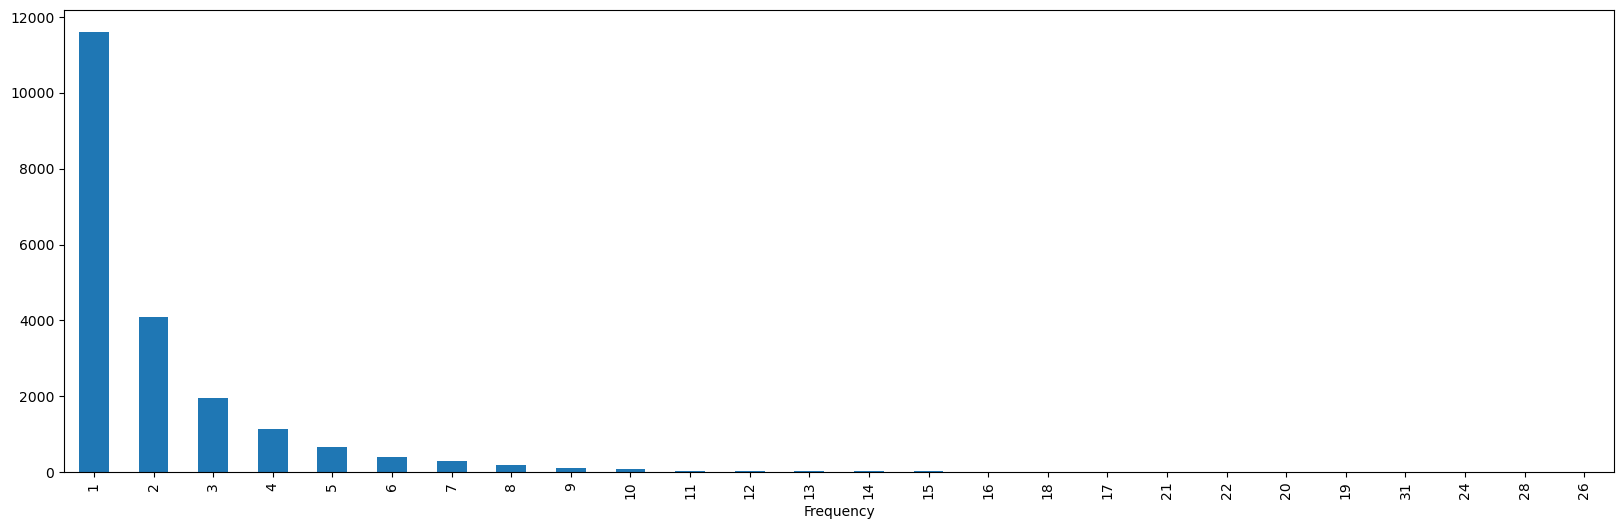

In [152]:
rfm.Frequency.value_counts().plot(kind = 'bar', figsize = (20,6));

**Consultas que puedo resolver en este punto**

In [153]:
# ¿Cuántos clientes han ralizado solo una compra?
rfm.Frequency[rfm.Frequency == 1].shape[0]

11606

In [154]:
# Calcular el porcentaje de clientes con una comrpa
clientes_una_compra = rfm.Frequency[rfm.Frequency == 1].shape[0]

total_clientes = rfm.shape[0]

(clientes_una_compra / total_clientes) * 100

56.10015467904099

In [155]:
# ¿Cuál es la frecuencia de compra promedio?
rfm.Frequency.mean()

2.109628770301624

In [156]:
# ¿Cuántos clientes han ralizado más de 10 compras?
rfm.Frequency[rfm.Frequency >= 10].shape[0]

253

In [157]:
# Calcular el porcentaje de clientes que han realizado más de 3 compras
clientes_mas_de_3_compras = rfm[rfm['Frequency'] > 3].shape[0]

total_clientes = rfm.shape[0]

(clientes_mas_de_3_compras / total_clientes) * 100

14.767014694508894

In [158]:
# ¿Cuáles son los clientes más leales? Top 10
rfm.sort_values('Frequency', ascending=False).head(10)

,Recency,Frequency
ID_Cliente,,
1703,8,31
15942,5,28
17446,32,26
12091,11,24
15553,16,22
10569,8,22
17757,16,22
15294,34,21
16192,11,21


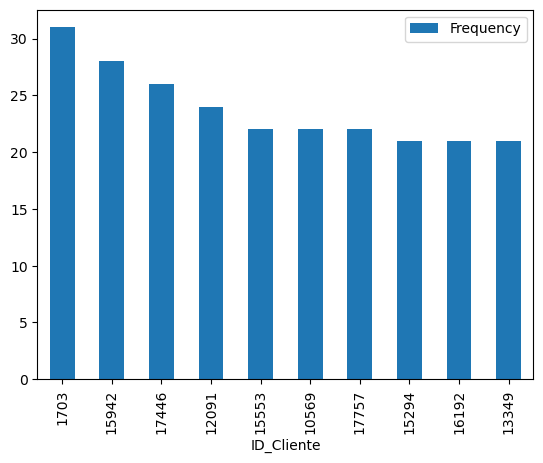

In [159]:
rfm.sort_values('Frequency', ascending=False).head(10).plot(kind='bar', y='Frequency');

**Observación**

- La mayoría de clientes realizaron solo una compra, aproximadamente 11k, que equivalen casi a la mitad de los clientes.
- Hay clientes que tienen una recurrencia muy alta, pero representan una minoría.

**Propuesta**

- Incrementar la frecuencia de compra en un articulo podría suponer unos ingresos considerables.

## Valor monetario

**Cuánto dinero ha gastado un cliente**

In [160]:
productos.head()

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32


In [161]:
# Calcular V. Monetario para cada cliente, que es la suma de todos los Precio_Total de sus transacciones.
rfm['Monetary'] = productos.groupby('ID_Cliente')['Total_Venta'].sum()
rfm

,Recency,Frequency,Monetary
ID_Cliente,,,
1,344,1,65.16
2,195,2,68.31
3,364,1,24.60
4,52,2,139.85
5,179,5,143.81
...,...,...,...
22621,21,1,31.26
22622,15,1,18.21
22623,10,1,365.25


In [162]:
# Verificamos que se ha calculado correctamente
productos[productos['ID_Cliente'] == 2]

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00


In [163]:
# Observar la distribución
rfm['Monetary'].describe()

count    20688.000000
mean       103.819227
std        107.361102
min          0.690000
25%         28.020000
50%         61.920000
75%        141.297500
max        500.000000
Name: Monetary, dtype: float64

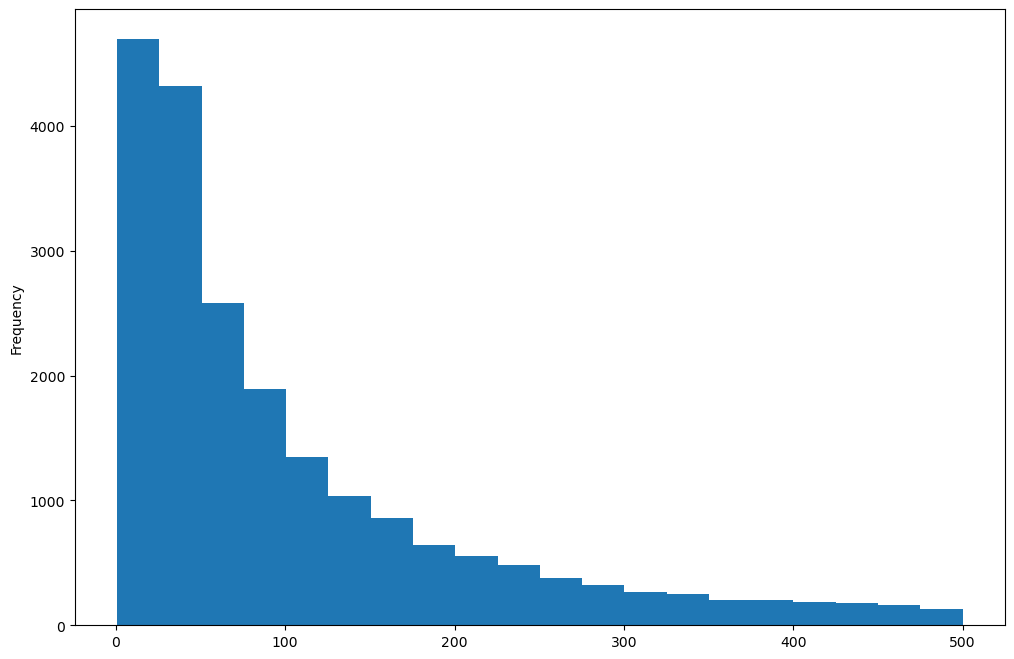

In [164]:
rfm.Monetary.plot(kind = 'hist', bins = 20, figsize = (12,8));

**Consultas que puedo resolver en este punto**

In [165]:
# ¿Cuál es el gasto promedio por cliente?
rfm['Monetary'].mean()

103.81922660479506

In [166]:
# ¿Quiénes son los clientes que más dinero han gastado? Top 50
rfm.sort_values('Monetary', ascending=False).head(50)

,Recency,Frequency,Monetary
ID_Cliente,,,
628,297,1,500.00
7463,258,5,499.95
12807,53,2,499.92
11381,12,2,499.78
1552,305,5,499.68
10624,19,14,499.63
21580,2,5,499.62
13273,57,8,499.34
17779,30,12,499.27


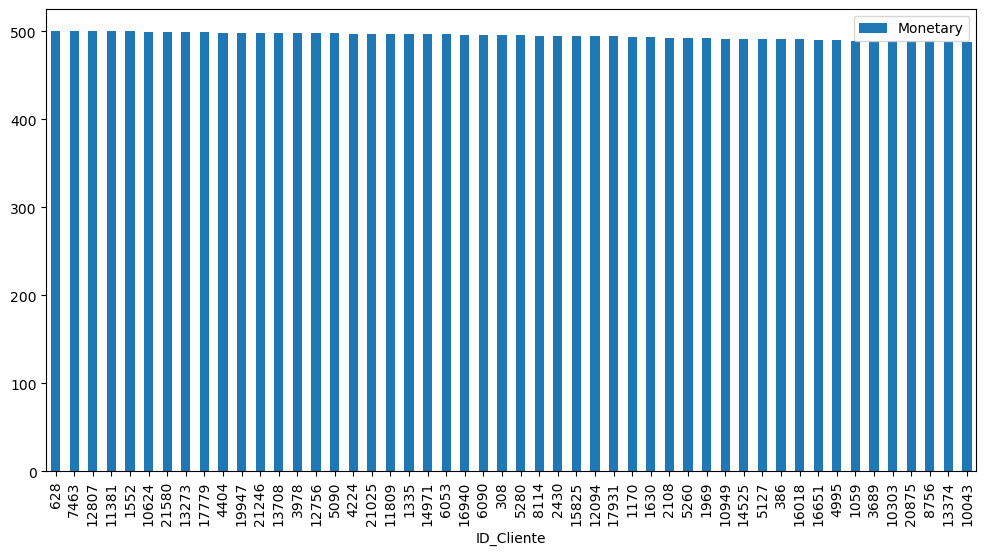

In [167]:
rfm.sort_values('Monetary', ascending=False).head(50).plot(kind='bar', y='Monetary', figsize = (12,6));

In [168]:
# ¿Qué clientes generan el 80% de los ingresos?

# Calcular el ingreso total
ingreso_total = rfm['Monetary'].sum()

# Ordenar el DataFrame por Monetary de mayor a menor
rfm_ord = rfm.sort_values(by='Monetary', ascending=False)

# Calcular la suma acumulada de los ingresos de los clientes
rfm_ord['Monetary_acumulado'] = rfm_ord['Monetary'].cumsum()

# Filtrar los clientes que representan el 80% del ingreso
clientes_80_ingreso = rfm_ord[rfm_ord['Monetary_acumulado'] <= 0.8 * ingreso_total]

# Mostrar el número de clientes
print(f"Número de clientes que generan el 80% de los ingresos: {len(clientes_80_ingreso)}")

# Mostrar los clientes
clientes_80_ingreso.head()


Número de clientes que generan el 80% de los ingresos: 8624


,Recency,Frequency,Monetary,Monetary_acumulado
ID_Cliente,,,,
628,297,1,500.00,500.00
7463,258,5,499.95,999.95
12807,53,2,499.92,1499.87
11381,12,2,499.78,1999.65
1552,305,5,499.68,2499.33


**Observación**

- El gasto promedio de los clientes es al rededor de 103, pero con una desviación estándar bastante alta, lo que confirma que hay una gran variabilidad en el valor de las transacciones.
- La mitad de los clientes han gastado aproximadamente 62
- Por otro lado, con pocos clientes, 8k se generan el 80% de los ingresos

**Objetivo**

- Identificar a los clientes con alto valor y aumentar la retención de estos perfiles debería ser prioritario

## Generar puntuaciones para Recency, Frequency y Monetary

**Revisamos Recency**

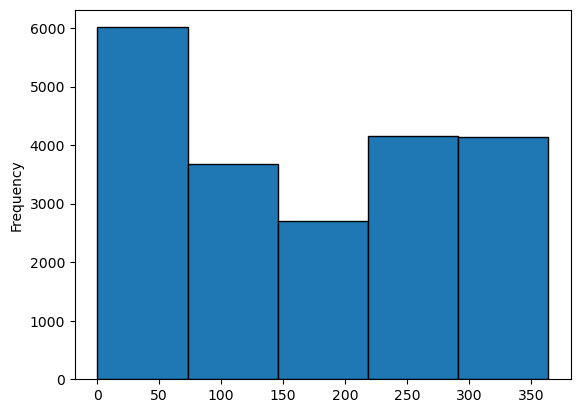

In [169]:
# Dibujamos un histograma con 5 cortes para clarificar como deberían ser los mismos:
rfm.Recency.plot(kind='hist', bins=5, edgecolor = 'black');

Podría establecer los grupos dividiendo los datos en percentiles con el método qcut, asignando aproximadamente el mismo número de observaciones a cada grupo (un 20%). Sin embargo, esto no refleja necesariamente los cortes que me interesan según los valores reales de la variable.

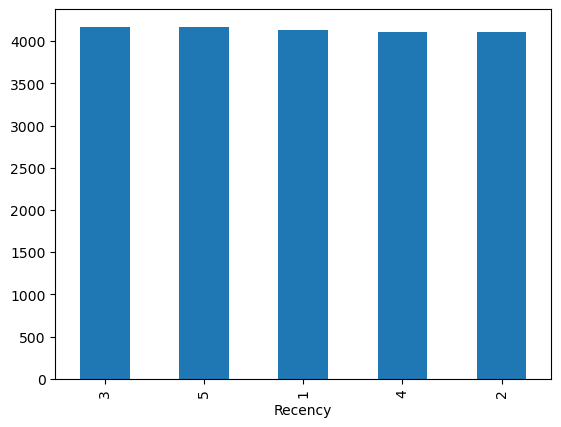

In [170]:
# El q = 5 me asigna un 20% a cada corte
pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).value_counts().plot(kind = 'bar');

**Aplicar los cortes con cut()**

Sintaxis del método cut()

pd.cut(x, bins[], labels=None)
- x: La serie o columna que queremos dividir.
- bins: Los grupos en los que queremos dividir los datos. **Incluído por defecto el límite superior**, pero no el inferior.
- labels: Etiquetas para asignar a cada grupo.
- Podemos incluir el valor mínimo (ej. el cero) con: include_lowest=True

**Establecer grupos de corte**

- Queremos 5 cortes
- La idea es que los cortes se distribuyan de la siguiente manera: 0-60, 60-120, 120-180, 180-240, 240-resto de valores...
- Para ajustar el resto de valores usaremos el máximo de la variable Recency
- El cliente que realiza la compra más reciente es mejor, por ello las etiquetas deben ir inveridas


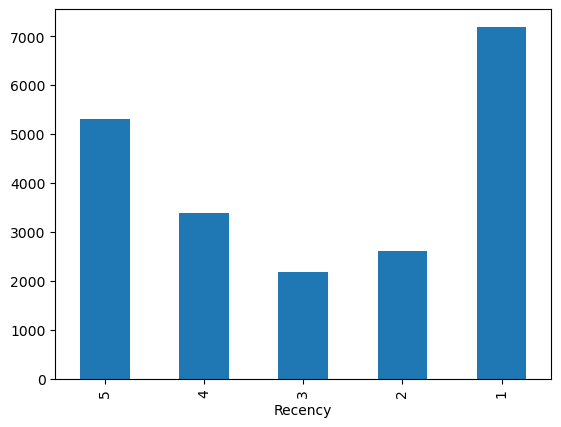

In [171]:
corte_prueba_r = pd.cut(rfm['Recency'], bins=[0, 60, 120, 180, 240, rfm['Recency'].max()], labels=[5, 4, 3, 2, 1],include_lowest=True )
corte_prueba_r.value_counts(sort = False).plot(kind = 'bar');

### Grupos de corte para Recency: 


pd.cut(rfm['Recency'], bins=[0, 60, 120, 180, 240, rfm['Recency'].max()], labels=[5, 4, 3, 2, 1],include_lowest=True )

**Revisamos Frequency**

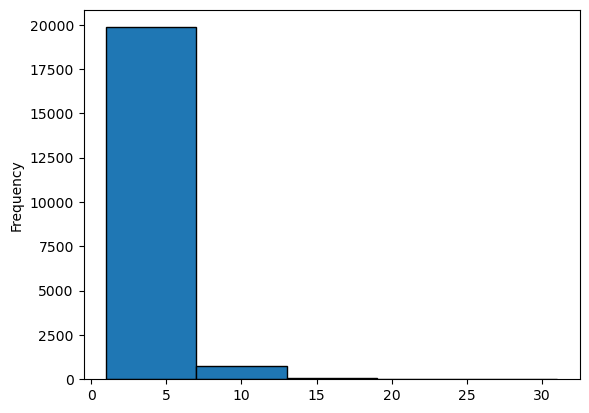

In [172]:
# Dibujamos un histograma con 5 cortes para clarificar como deberían ser los mismos:
rfm.Frequency.plot(kind='hist', bins=5, edgecolor = 'black');

In [173]:
# Observamos su distribución
rfm.Frequency.describe()

count    20688.000000
mean         2.109629
std          1.983245
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         31.000000
Name: Frequency, dtype: float64

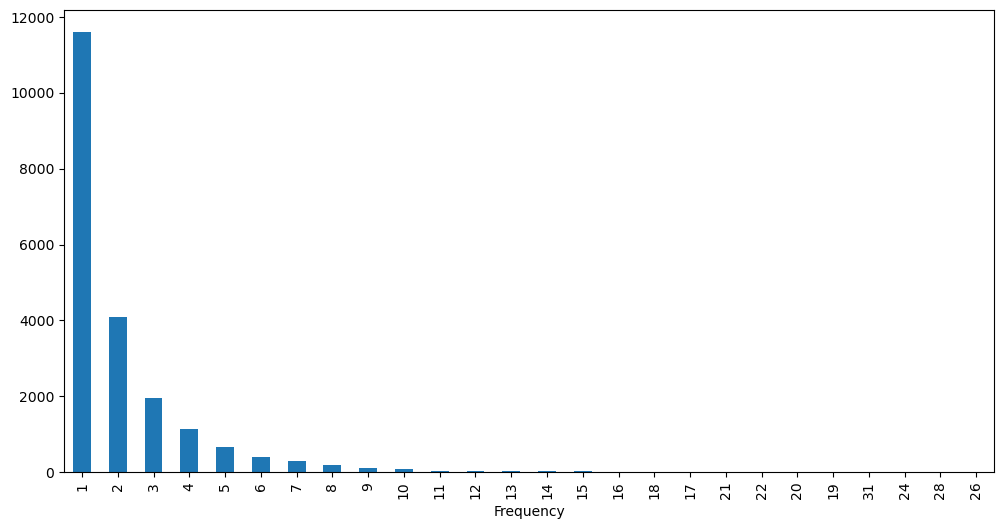

In [174]:
# recurrimos a value_counts para observar sus valores
rfm.Frequency.value_counts().plot(kind='bar', figsize = (12,6));

Aqui tenemos que asumir otro criterio de corte, porque las frecuencias son también diferentes, agrupándose en los primeros valores.

- Una opción puede ser: 1,2,3,4, resto de valores.
- También podemos agrupar algunos de los segmentos, por ejemplo: 1, 2-3, 4-5, 6-8, 9 y más...
- Para ajustar el resto de valores usaremos el máximo de la variable Frequency

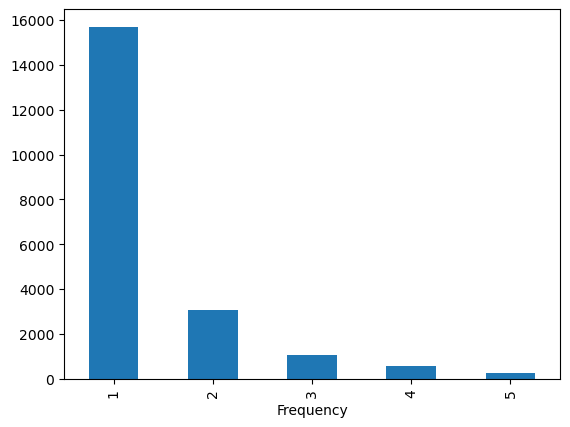

In [175]:
corte_prueba_f = pd.cut(rfm['Frequency'], bins=[1, 2, 4, 6, 9, rfm['Frequency'].max()], labels=[1, 2, 3, 4, 5],include_lowest=True)
corte_prueba_f.value_counts(sort = False).plot(kind = 'bar');

### Grupos de corte para Frequency: Basado en clientes más frecuentes

pd.cut(rfm['Frequency'], bins=[1, 2, 4, 6, 9, rfm['Frequency'].max()], labels=[1, 2, 3, 4, 5],include_lowest=True)

**Revisamos Monetary**

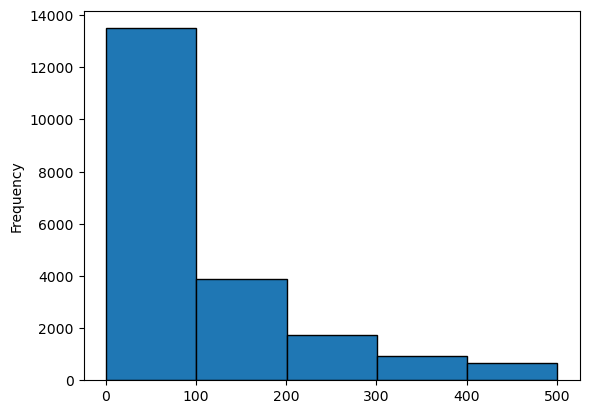

In [176]:
rfm.Monetary.plot(kind='hist', bins=5, edgecolor = 'black');

In [177]:
# Observamos su distribución
rfm.Monetary.describe()

count    20688.000000
mean       103.819227
std        107.361102
min          0.690000
25%         28.020000
50%         61.920000
75%        141.297500
max        500.000000
Name: Monetary, dtype: float64

En este caso, podríamos establecer valores que representen grupos de compras basados en importes estandar:

- 30, 70, 150, 300, resto de valores...

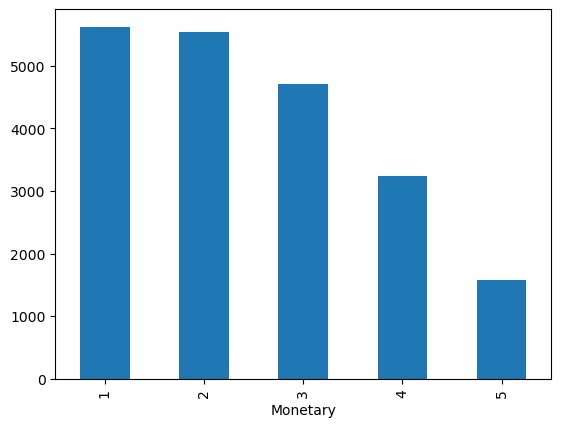

In [178]:
corte_prueba_m = pd.cut(rfm['Monetary'], bins=[0, 30, 70, 150, 300, rfm['Monetary'].max()], labels=[1, 2, 3, 4, 5])
corte_prueba_m.value_counts(sort = False).plot(kind = 'bar');

### Grupos de corte para Monetary: Basado en ticket medio

pd.cut(rfm['Monetary'], bins=[0, 30, 70, 150, 300, rfm['Monetary'].max()], labels=[1, 2, 3, 4, 5])

## Asignar las puntuaciones con los puntos de corte personalizados

In [179]:
# Calcular las puntuaciones RFM
rfm['r'] = pd.cut(rfm['Recency'], bins=[0, 60, 120, 180, 240, rfm['Recency'].max()], labels=[5, 4, 3, 2, 1],include_lowest=True ) # El cliente que realiza la compra más reciente es mejor, por ello el valor más alto
rfm['f'] = pd.cut(rfm['Frequency'], bins=[1, 2, 4, 6, 9, rfm['Frequency'].max()], labels=[1, 2, 3, 4, 5],include_lowest=True)
rfm['m'] = pd.cut(rfm['Monetary'], bins=[0, 30, 70, 150, 300, rfm['Monetary'].max()], labels=[1, 2, 3, 4, 5])

In [180]:
rfm.head()

,Recency,Frequency,Monetary,r,f,m
ID_Cliente,,,,,,
1,344,1,65.16,1,1,2
2,195,2,68.31,2,1,2
3,364,1,24.60,1,1,1
4,52,2,139.85,5,1,3
5,179,5,143.81,3,3,3


In [181]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20688 entries, 1 to 22625
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Recency    20688 non-null  int64   
 1   Frequency  20688 non-null  int64   
 2   Monetary   20688 non-null  float64 
 3   r          20688 non-null  category
 4   f          20688 non-null  category
 5   m          20688 non-null  category
dtypes: category(3), float64(1), int64(2)
memory usage: 707.7 KB


## Crear el segmento

Nos permitirá un análisis táctico sobre los datos

In [182]:
# No funciona concatenando directamente
# rfm['RFM'] = rfm['r'] + rfm['f'] + rfm['m']
rfm.head()

,Recency,Frequency,Monetary,r,f,m
ID_Cliente,,,,,,
1,344,1,65.16,1,1,2
2,195,2,68.31,2,1,2
3,364,1,24.60,1,1,1
4,52,2,139.85,5,1,3
5,179,5,143.81,3,3,3


In [183]:
# Debemos convertir cada variable a str
rfm['RFM'] = rfm['r'].astype(str) + rfm['f'].astype(str) + rfm['m'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,r,f,m,RFM
ID_Cliente,,,,,,,
1,344,1,65.16,1,1,2,112
2,195,2,68.31,2,1,2,212
3,364,1,24.60,1,1,1,111
4,52,2,139.85,5,1,3,513
5,179,5,143.81,3,3,3,333


In [184]:
# Verificamos por ejemplo los segmentos inactivos
rfm[rfm['RFM'] == '111']

,Recency,Frequency,Monetary,r,f,m,RFM
ID_Cliente,,,,,,,
3,364,1,24.60,1,1,1,111
11,337,1,12.70,1,1,1,111
15,357,1,11.46,1,1,1,111
18,346,1,7.60,1,1,1,111
22,351,1,13.50,1,1,1,111
...,...,...,...,...,...,...,...
21925,242,1,16.76,1,1,1,111
22127,253,1,12.56,1,1,1,111
22128,244,1,18.93,1,1,1,111


## Definir un segmento personalizado

Nos permitirá un análisis más estratégico

In [185]:
def segmentar_clientes(fila):
    r, f, m = str(fila['r']), str(fila['f']), str(fila['m'])
    
    # Definir condiciones previamente para simplificar el código
    es_alto_r = r in ['4', '5']
    es_alto_f = f in ['4', '5']
    es_alto_m = m in ['4', '5']
    
    es_medio_r = r in ['3']
    es_medio_f = f in ['3']
    es_medio_m = m in ['3']
    
    es_bajo_r = r in ['1', '2']
    es_bajo_f = f in ['1', '2']
    es_bajo_m = m in ['1', '2']
    
    # Aplicar la lógica de los segmentos
    if es_alto_r and es_alto_f and es_alto_m:
        return 'Campeones'
    elif es_alto_r and es_alto_f and (es_alto_m or es_medio_m):
        return 'Clientes Leales'
    elif es_medio_r and es_alto_f and es_alto_m:
        return 'Clientes Rentables'
    elif es_bajo_r and es_medio_f and es_medio_m:
        return 'Leales Potenciales'
    elif es_bajo_r and es_bajo_f and es_alto_m:
        return 'Grandes Gastadores'
    elif es_alto_r and es_bajo_f and es_bajo_m:
        return 'Clientes Recientes'
    elif es_medio_r and es_medio_f and es_medio_m:
        return 'Prometedores'
    elif es_bajo_r and es_bajo_f and es_bajo_m:
        return 'En Riesgo'
    else:
        return 'Dudosos'

# Aplicar la función
rfm['Segmento'] = rfm.apply(segmentar_clientes, axis=1)

In [186]:
rfm

,Recency,Frequency,Monetary,r,f,m,RFM,Segmento
ID_Cliente,,,,,,,,
1,344,1,65.16,1,1,2,112,En Riesgo
2,195,2,68.31,2,1,2,212,En Riesgo
3,364,1,24.60,1,1,1,111,En Riesgo
4,52,2,139.85,5,1,3,513,Dudosos
5,179,5,143.81,3,3,3,333,Prometedores
...,...,...,...,...,...,...,...,...
22621,21,1,31.26,5,1,2,512,Clientes Recientes
22622,15,1,18.21,5,1,1,511,Clientes Recientes
22623,10,1,365.25,5,1,5,515,Dudosos


**Consultas RFM**

In [187]:
# ¿Cómo están distribuidos los segmentos?
rfm.Segmento.value_counts()

Segmento
Dudosos               8621
En Riesgo             5951
Clientes Recientes    3933
Grandes Gastadores    1409
Campeones              582
Clientes Leales         67
Leales Potenciales      65
Clientes Rentables      39
Prometedores            21
Name: count, dtype: int64

In [188]:
# ¿Cuál es el cliente promedio?
rfm[['Recency', 'Frequency', 'Monetary']].mean()

Recency      168.527020
Frequency      2.109629
Monetary     103.819227
dtype: float64

In [189]:
rfm[['Recency', 'Frequency', 'Monetary']].median()

Recency      166.00
Frequency      1.00
Monetary      61.92
dtype: float64

In [190]:
# ¿Cuál es el total de ventas por segmento?
rfm.groupby('Segmento')['Monetary'].sum()

Segmento
Campeones              193377.01
Clientes Leales          7802.28
Clientes Recientes     133473.22
Clientes Rentables      12695.43
Dudosos               1247011.72
En Riesgo              184709.84
Grandes Gastadores     358809.03
Leales Potenciales       7470.30
Prometedores             2463.33
Name: Monetary, dtype: float64

In [191]:
# ¿Cuál es la venta media por segmento?
rfm.groupby('Segmento')['Monetary'].mean()

Segmento
Campeones             332.262904
Clientes Leales       116.451940
Clientes Recientes     33.936745
Clientes Rentables    325.523846
Dudosos               144.648152
En Riesgo              31.038454
Grandes Gastadores    254.655096
Leales Potenciales    114.927692
Prometedores          117.301429
Name: Monetary, dtype: float64

In [192]:
# ¿Qué porcentaje del total de ingresos representa cada segmento?
total_monetary = rfm['Monetary'].sum()
rfm.groupby('Segmento')['Monetary'].sum() / total_monetary * 100

Segmento
Campeones              9.003441
Clientes Leales        0.363266
Clientes Recientes     6.214380
Clientes Rentables     0.591087
Dudosos               58.059627
En Riesgo              8.599907
Grandes Gastadores    16.705792
Leales Potenciales     0.347810
Prometedores           0.114690
Name: Monetary, dtype: float64

**Gráficos mediante otras librerías**

Si queremos recurrir a gráficos algo más elaborados de los que nos proporciona Pandas, podemos apoyarnos en la IA para crearlos con otras librerías.
En este caso haremos treemap con las librerías matplotlib y squarify. (Debemos recordar instalarlas en Anaconda)



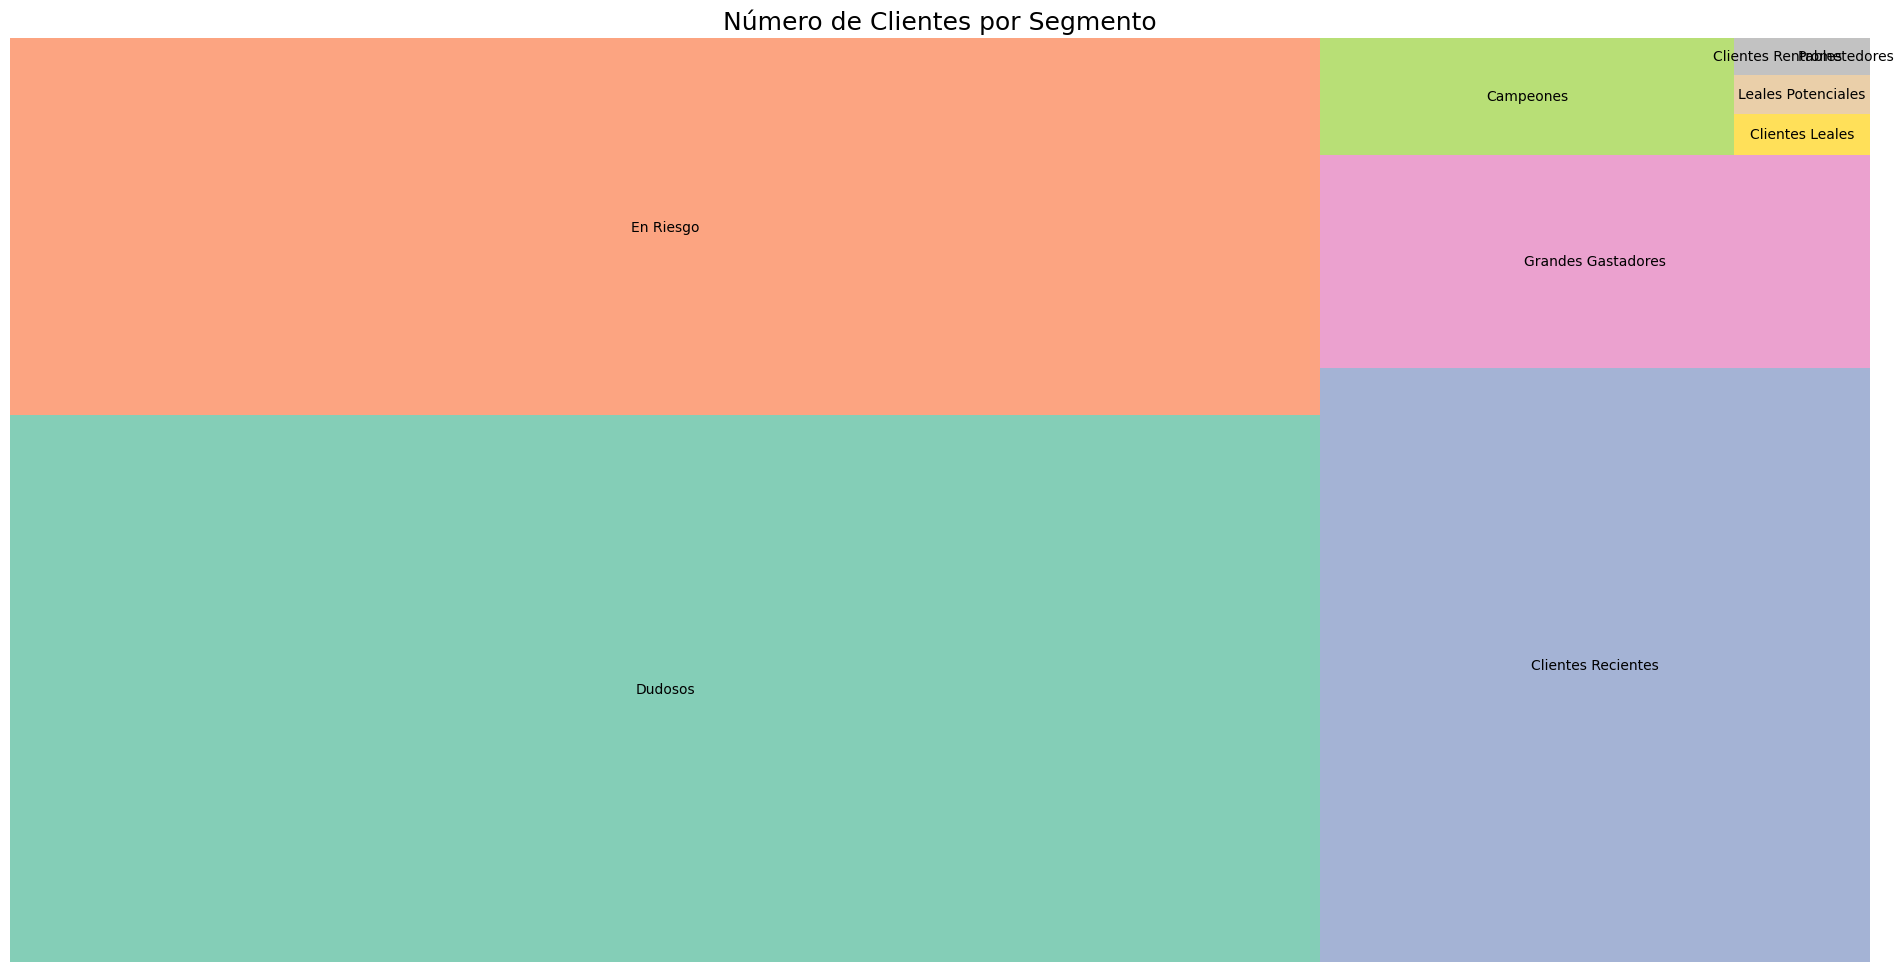

In [193]:
# Representación de clientes por segmento

import squarify
import matplotlib.pyplot as plt

# Contar el número de clientes por segmento
clientes_por_segmento = rfm['Segmento'].value_counts()

# Definir una lista de colores con Matplotlib
cmap = plt.cm.Set2(range(len(clientes_por_segmento)))

# Crear el treemap
plt.figure(figsize=(24, 12))
squarify.plot(sizes=clientes_por_segmento.values, label=clientes_por_segmento.index, color=cmap, alpha=0.8)

# Añadir el título y eliminar ejes
plt.title('Número de Clientes por Segmento', fontsize=18)
plt.axis('off')

plt.show()

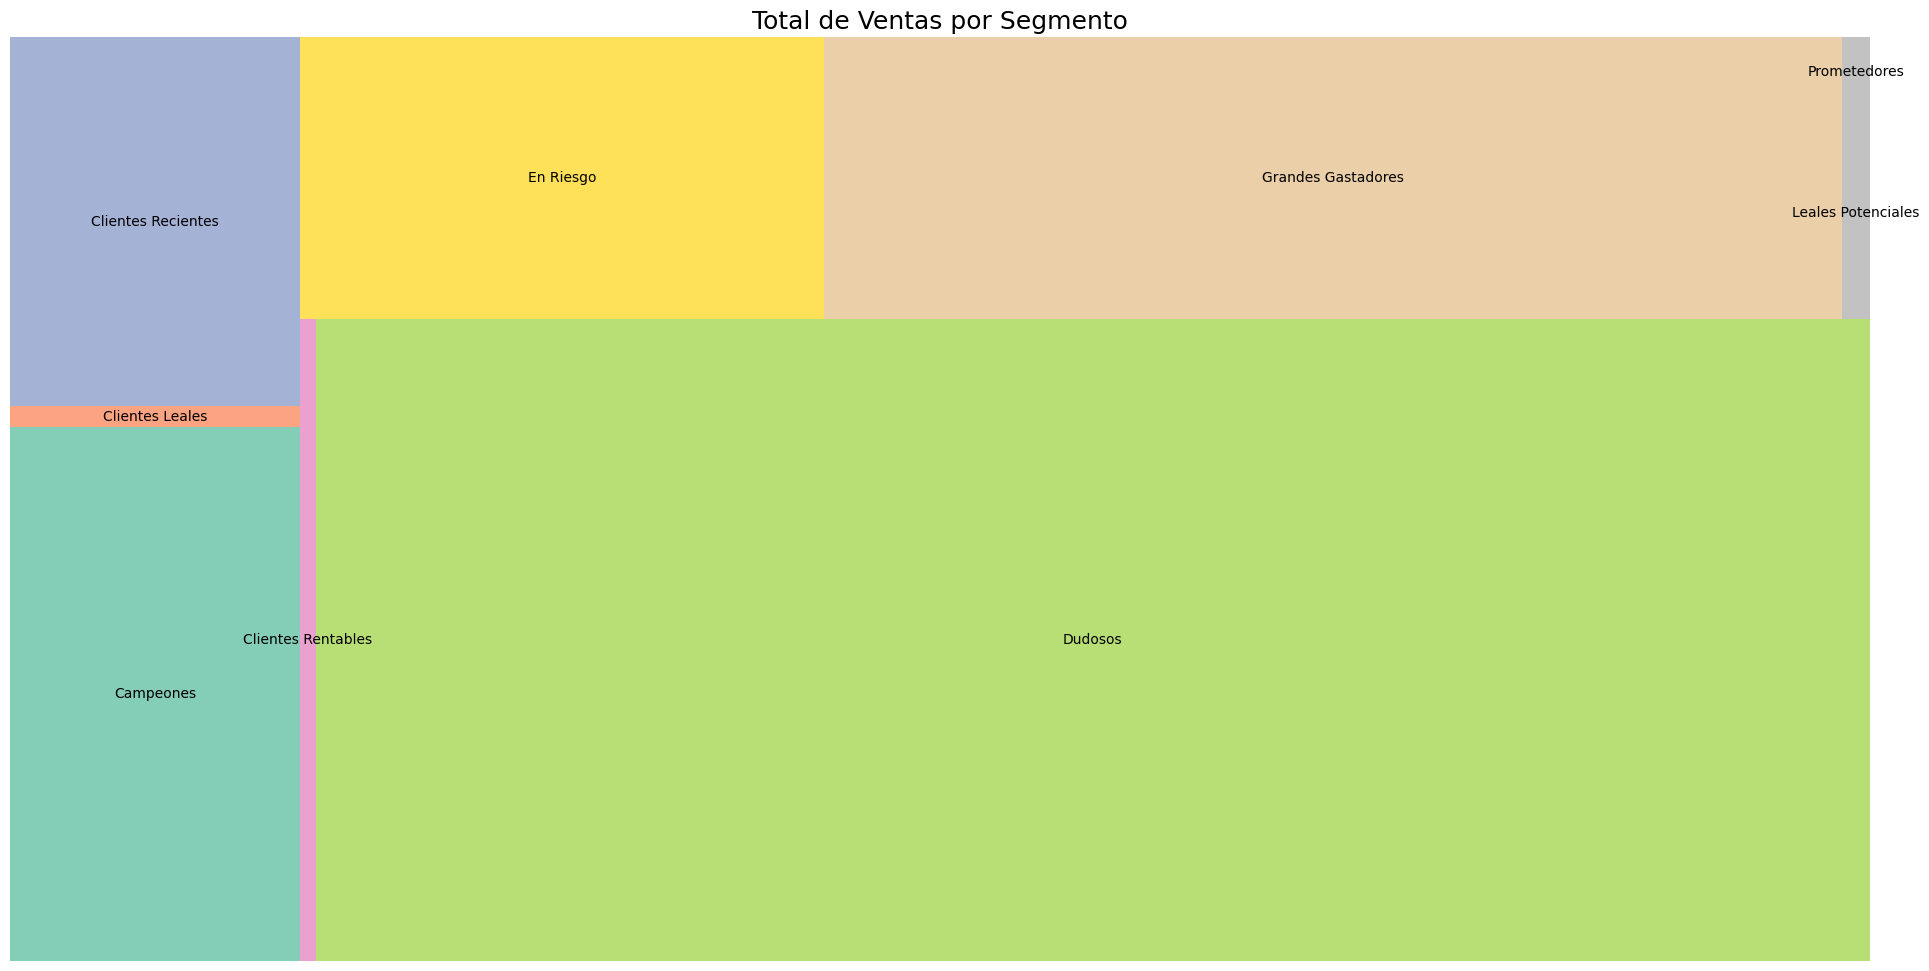

In [194]:
# Representación de Ventas por segmento

# Agrupar y sumar el Total_Venta por segmento (monetary)
ventas_por_segmento = rfm.groupby('Segmento')['Monetary'].sum()

# Definir una lista de colores con Matplotlib
cmap = plt.cm.Set2(range(len(ventas_por_segmento)))

# Crear el treemap
plt.figure(figsize=(24, 12))
squarify.plot(sizes=ventas_por_segmento.values, label=ventas_por_segmento.index, color=cmap, alpha=0.8)

# Añadir el título y eliminar ejes
plt.title('Total de Ventas por Segmento', fontsize=18)
plt.axis('off')

plt.show()

### Propuesta de acción de márketing

 **1. Campaña de Reactivación:** Dirigida a clientes inactivos o en riesgo, ofreciéndoles incentivos para volver a comprar.
 
- En Riesgo: Clientes con baja recencia, frecuencia y valor monetario. Son clientes que probablemente han dejado de comprar por completo.
- Dudosos: Son clientes que no han mostrado un patrón consistente, y es probable que estén inactivos o a punto de perderse.
    
 **2. Campaña de Conversión de Compradores Únicos:** Motivar a los clientes que han comprado solo una vez a convertirse en recurrentes mediante ofertas y seguimiento personalizado.
 
 - Clientes Recientes: Compraron por primera vez recientemente, pero no han repetido compra.
 - Prometedores: Clientes con valores medios en todas las métricas. Han mostrado interés, pero aún no han demostrado lealtad o valor alto.
 - Clientes Rentables: Compran con frecuencia y gastan bien, pero podrían no haber comprado recientemente.
      
 **3. Campaña de Upselling/Cross-selling:** Aumentar el valor promedio de compra mediante paquetes, productos premium y descuentos por gasto mínimo.

- Clientes Rentables: Compran con frecuencia y gastan bastante, pero pueden no estar comprando productos de mayor valor.
- Leales Potenciales: Han sido consistentes, pero con un valor monetario moderado. Pueden ser incentivados a gastar más.
- Grandes Gastadores: Compran de forma esporádica, pero cuando lo hacen, gastan mucho. Estos clientes podrían comprar con mayor frecuencia o agregar más productos a su carrito.

**1. Campaña de Reactivación**

In [199]:
# Filtrar clientes inactivos 
segmentos_reactivacion = ['En Riesgo','Dudosos']

# Filtrar los clientes pertenecientes a estos segmentos
clientes_inactivos = rfm[rfm['Segmento'].isin(segmentos_reactivacion)]
clientes_inactivos

,Recency,Frequency,Monetary,r,f,m,RFM,Segmento
ID_Cliente,,,,,,,,
1,344,1,65.16,1,1,2,112,En Riesgo
2,195,2,68.31,2,1,2,212,En Riesgo
3,364,1,24.60,1,1,1,111,En Riesgo
4,52,2,139.85,5,1,3,513,Dudosos
6,275,1,91.66,1,1,3,113,Dudosos
...,...,...,...,...,...,...,...,...
22617,19,1,84.48,5,1,3,513,Dudosos
22618,164,1,9.54,3,1,1,311,Dudosos
22623,10,1,365.25,5,1,5,515,Dudosos


**2. Campaña de Conversión**

In [200]:
# Filtrar clientes con baja o mediana frecuencia 
segmentos_conversion = ['Clientes Recientes', 'Prometedores', 'Clientes Rentables']

# Filtrar los clientes pertenecientes a estos segmentos
clientes_conversion = rfm[rfm['Segmento'].isin(segmentos_conversion)]
clientes_conversion

,Recency,Frequency,Monetary,r,f,m,RFM,Segmento
ID_Cliente,,,,,,,,
5,179,5,143.81,3,3,3,333,Prometedores
7,87,1,53.52,4,1,2,412,Clientes Recientes
23,101,1,5.52,4,1,1,411,Clientes Recientes
84,134,6,82.80,3,3,3,333,Prometedores
108,93,2,43.16,4,1,2,412,Clientes Recientes
...,...,...,...,...,...,...,...,...
22616,66,1,12.06,4,1,1,411,Clientes Recientes
22619,27,1,18.54,5,1,1,511,Clientes Recientes
22620,60,1,43.00,5,1,2,512,Clientes Recientes


**3. Campaña de Upselling/Cross-selling**

In [201]:
# Filtrar clientes con potencial de aumento de gasto 
segmentos_upselling = ['Clientes Rentables', 'Leales Potenciales', 'Grandes Gastadores']

# Filtrar los clientes pertenecientes a estos segmentos
clientes_upselling = rfm[rfm['Segmento'].isin(segmentos_upselling)]
clientes_upselling

,Recency,Frequency,Monetary,r,f,m,RFM,Segmento
ID_Cliente,,,,,,,,
10,323,1,220.62,1,1,4,114,Grandes Gastadores
13,324,2,159.72,1,1,4,114,Grandes Gastadores
14,311,3,402.42,1,2,5,125,Grandes Gastadores
16,257,2,310.80,1,1,5,115,Grandes Gastadores
19,262,1,199.90,1,1,4,114,Grandes Gastadores
...,...,...,...,...,...,...,...,...
21804,187,1,213.91,2,1,4,214,Grandes Gastadores
21883,198,1,159.12,2,1,4,214,Grandes Gastadores
21958,227,1,158.85,2,1,4,214,Grandes Gastadores


## Código RFM unificado

Se deben adaptar los nombres de las variables con las que se calculan las tres medidas para reutilizarlo en otros proyectos

In [202]:
# # Paso 1: Calcular Recency, Frequency, y Monetary

# # Definir la fecha de referencia (puede ser la fecha actual o la fecha máxima del dataset)
# fecha_max = productos['Fecha'].max()

# # Calcular recencia en dias para cada cliente
# rfm = productos.groupby('ID_Cliente').agg(Recency=('Fecha', lambda x: (fecha_max - x.max()).days))
# # Calcular frecuencia de compra por cliente
# rfm['Frequency'] = productos.groupby('ID_Cliente')['ID_Transaccion'].nunique()
# # Calcular V. Monetario para cada cliente, que es la suma de todos los Precio_Total de sus transacciones.
# rfm['Monetary'] = productos.groupby('ID_Cliente')['Total_Venta'].sum()


# # Calcular las puntuaciones RFM
# rfm['r'] = pd.cut(rfm['Recency'], bins=[0, 60, 120, 180, 240, rfm['Recency'].max()], labels=[5, 4, 3, 2, 1],include_lowest=True ) # El cliente que realiza la compra más reciente es mejor, por ello el valor más alto
# rfm['f'] = pd.cut(rfm['Frequency'], bins=[1, 2, 4, 6, 9, rfm['Frequency'].max()], labels=[1, 2, 3, 4, 5],include_lowest=True)
# rfm['m'] = pd.cut(rfm['Monetary'], bins=[0, 30, 70, 150, 300, rfm['Monetary'].max()], labels=[1, 2, 3, 4, 5])


# # Debemos convertir cada variable a str
# rfm['RFM'] = rfm['r'].astype(str) + rfm['f'].astype(str) + rfm['m'].astype(str)

# # Paso 3: Crear segmentos personalizados basados en RFM

# def segmentar_clientes(fila):
#     r, f, m = str(fila['r']), str(fila['f']), str(fila['m'])
    
#     # Definir condiciones previamente para simplificar el código
#     es_alto_r = r in ['4', '5']
#     es_alto_f = f in ['4', '5']
#     es_alto_m = m in ['4', '5']
    
#     es_medio_r = r in ['3']
#     es_medio_f = f in ['3']
#     es_medio_m = m in ['3']
    
#     es_bajo_r = r in ['1', '2']
#     es_bajo_f = f in ['1', '2']
#     es_bajo_m = m in ['1', '2']
    
#     # Aplicar la lógica de los segmentos
#     if es_alto_r and es_alto_f and es_alto_m:
#         return 'Campeones'
#     elif es_alto_r and es_alto_f and (es_alto_m or es_medio_m):
#         return 'Clientes Leales'
#     elif es_medio_r and es_alto_f and es_alto_m:
#         return 'Clientes Rentables'
#     elif es_bajo_r and es_medio_f and es_medio_m:
#         return 'Leales Potenciales'
#     elif es_bajo_r and es_bajo_f and es_alto_m:
#         return 'Grandes Gastadores'
#     elif es_alto_r and es_bajo_f and es_bajo_m:
#         return 'Clientes Recientes'
#     elif es_medio_r and es_medio_f and es_medio_m:
#         return 'Prometedores'
#     elif es_bajo_r and es_bajo_f and es_bajo_m:
#         return 'En Riesgo'
#     else:
#         return 'Dudosos'

# # Aplicar la función
# rfm['Segmento'] = rfm.apply(segmentar_clientes, axis=1) 